# 1. Tóm tắt mô hình toán học
**Biến quyết định:**
- $x_1$: Ngân sách đầu tư hạ tầng số (nghìn tỷ VND)
- $x_2$: Ngân sách đầu tư AI và dữ liệu (nghìn tỷ VND)
- $x_3$: Ngân sách đầu tư nhân lực số (nghìn tỷ VND)
- $x_4$: Ngân sách đầu tư R&D công nghệ (nghìn tỷ VND)

**Hàm mục tiêu:** Tối đa hóa tổng GDP tăng thêm (Z, đơn vị: nghìn tỷ VND)
$$\max Z = 0.85x_1 + 1.20x_2 + 0.95x_3 + 1.35x_4$$
*(Lưu ý: Do hệ số mục tiêu phản ánh số đồng GDP tăng thêm trên 1 đồng đầu tư, nên khi $x_i$ dùng đơn vị nghìn tỷ VND, $Z$ cũng tự động mang đơn vị là nghìn tỷ VND).*

**Các ràng buộc:**
1. Ràng buộc ngân sách tổng: $x_1 + x_2 + x_3 + x_4 \le 100$
2. Hạ tầng số tối thiểu: $x_1 \ge 25$
3. AI & Dữ liệu tối thiểu: $x_2 \ge 15$
4. Nhân lực số tối thiểu: $x_3 \ge 20$
5. R&D tối thiểu: $x_4 \ge 10$
6. Tỷ trọng công nghệ chiến lược: $x_2 + x_4 \ge 0.35(x_1 + x_2 + x_3 + x_4)$
7. Ràng buộc không âm: $x_1, x_2, x_3, x_4 \ge 0$

# 2. Phần lập trình

## Gộp và chuẩn hóa cho câu 2.4.1 & 2.4.2

In [1]:
import pulp
from scipy.optimize import linprog
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== CÂU 2.4.1: GIẢI BẰNG SCIPY ===")
c_scipy = [-0.85, -1.20, -0.95, -1.35]
A_ub = [
    [1, 1, 1, 1],                # C1
    [-1, 0, 0, 0],               # C2
    [0, -1, 0, 0],               # C3
    [0, 0, -1, 0],               # C4
    [0, 0, 0, -1],               # C5
    [0.35, -0.65, 0.35, -0.65]   # C6
]
b_ub = [100, -25, -15, -20, -10, 0]

res = linprog(c_scipy, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method='highs')
print(f"Trạng thái: {res.message}")
print(f"Phân bổ (x1, x2, x3, x4): {np.round(res.x, 2)}")
print(f"Giá trị Z*: {-res.fun:.2f} nghìn tỷ VND\n")

print("=== CÂU 2.4.2: GIẢI BẰNG PULP & IN GIÁ ĐỐI NGẪU ===")
prob = pulp.LpProblem("Budget_Allocation", pulp.LpMaximize)

x1 = pulp.LpVariable('x1_Infra', lowBound=0)
x2 = pulp.LpVariable('x2_AI', lowBound=0)
x3 = pulp.LpVariable('x3_HR', lowBound=0)
x4 = pulp.LpVariable('x4_RD', lowBound=0)

prob += 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4, "Total_GDP_Gain"

prob += (x1 + x2 + x3 + x4 <= 100), "C1_Total_Budget"
prob += (x1 >= 25), "C2_Min_Infra"
prob += (x2 >= 15), "C3_Min_AI"
prob += (x3 >= 20), "C4_Min_HR"
prob += (x4 >= 10), "C5_Min_RD"
prob += (x2 + x4 >= 0.35 * (x1 + x2 + x3 + x4)), "C6_Strategic_Tech"

prob.solve(pulp.PULP_CBC_CMD(msg=False))

# Lưu trữ lại giá trị để tái sử dụng ở các bước sau
z_base = pulp.value(prob.objective)
x_base = [x1.varValue, x2.varValue, x3.varValue, x4.varValue]

print(f"Phân bổ tối ưu PuLP: x1={x_base[0]}, x2={x_base[1]}, x3={x_base[2]}, x4={x_base[3]}")
print(f"Giá trị tối ưu Z* = {z_base} nghìn tỷ VND\n")

print("Giá đối ngẫu (Shadow Prices) của các ràng buộc:")
for name, constraint in prob.constraints.items():
    print(f" - {name}: {constraint.pi}")

=== CÂU 2.4.1: GIẢI BẰNG SCIPY ===
Trạng thái: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Phân bổ (x1, x2, x3, x4): [25. 15. 20. 40.]
Giá trị Z*: 112.25 nghìn tỷ VND

=== CÂU 2.4.2: GIẢI BẰNG PULP & IN GIÁ ĐỐI NGẪU ===
Phân bổ tối ưu PuLP: x1=25.0, x2=15.0, x3=20.0, x4=40.0
Giá trị tối ưu Z* = 112.25 nghìn tỷ VND

Giá đối ngẫu (Shadow Prices) của các ràng buộc:
 - C1_Total_Budget: 1.35
 - C2_Min_Infra: -0.5
 - C3_Min_AI: -0.15
 - C4_Min_HR: -0.4
 - C5_Min_RD: -0.0
 - C6_Strategic_Tech: -0.0


**Giải thích ý nghĩa Shadow Price:**
- **Ràng buộc ngân sách (C1_Total_Budget = 1.35):** Đây là giá trị quan trọng nhất. Ý nghĩa chính sách là: Nếu tăng trần ngân sách thêm 1 nghìn tỷ VND, tổng GDP kỳ vọng sẽ tăng thêm đúng 1.35 nghìn tỷ VND. Lý do là mô hình sẽ dồn 100% phần ngân sách nới lỏng này vào hạng mục có hệ số sinh lời cao nhất ($x_4$ - R&D với hệ số 1.35).
- Các ràng buộc C5 và C6 có shadow price = 0 nghĩa là chúng đang có điểm chênh (slack > 0), chưa bị chạm ngưỡng (non-binding). Thay đổi giới hạn các ràng buộc này không làm thay đổi giá trị Z*.

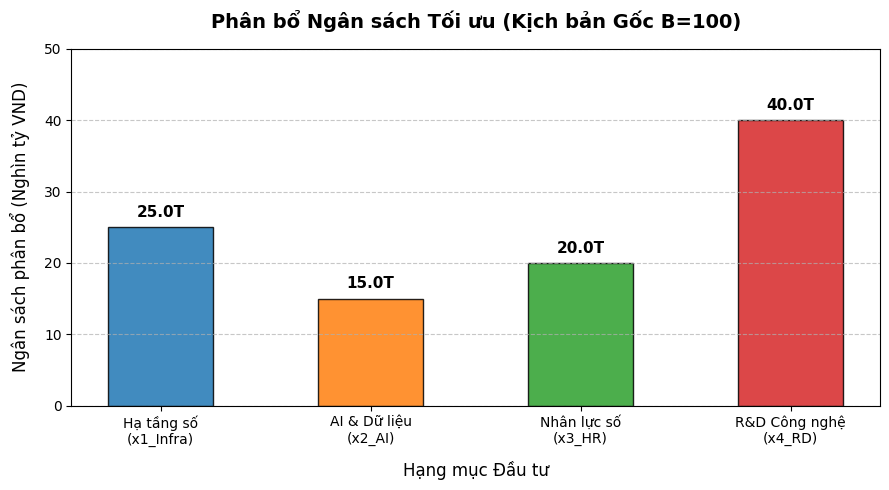

In [7]:
import matplotlib.pyplot as plt

# KẾT QUẢ ĐỘNG: Lấy từ biến x_base (chứa kết quả x1, x2, x3, x4) 
# đã được lưu sau khi chạy hàm prob.solve() ở cell trước đó.
# Không nhập tay (hardcode) để tránh lỗi lệch data!
categories = [
    'Hạ tầng số\n(x1_Infra)', 
    'AI & Dữ liệu\n(x2_AI)', 
    'Nhân lực số\n(x3_HR)', 
    'R&D Công nghệ\n(x4_RD)'
]
allocations = x_base 

# Cấu hình màu sắc chuyên nghiệp
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
plt.figure(figsize=(9, 5))
bars = plt.bar(categories, allocations, color=colors, width=0.5, edgecolor='black', alpha=0.85)

# Thêm số liệu cụ thể lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}T", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Cấu hình tiêu đề và trục
plt.title('Phân bổ Ngân sách Tối ưu (Kịch bản Gốc B=100)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hạng mục Đầu tư', fontsize=12, labelpad=10)
plt.ylabel('Ngân sách phân bổ (Nghìn tỷ VND)', fontsize=12, labelpad=10)

# Linh hoạt trục Y: Lấy cột cao nhất cộng thêm 10 để luôn có khoảng trống cho Text
plt.ylim(0, max(allocations) + 10)  

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

## Vẽ đường phân tích độ nhạy và dán nhãn cho 2.4.3

=== CÂU 2.4.3: PHÂN TÍCH ĐỘ NHẠY Z*(B) ===


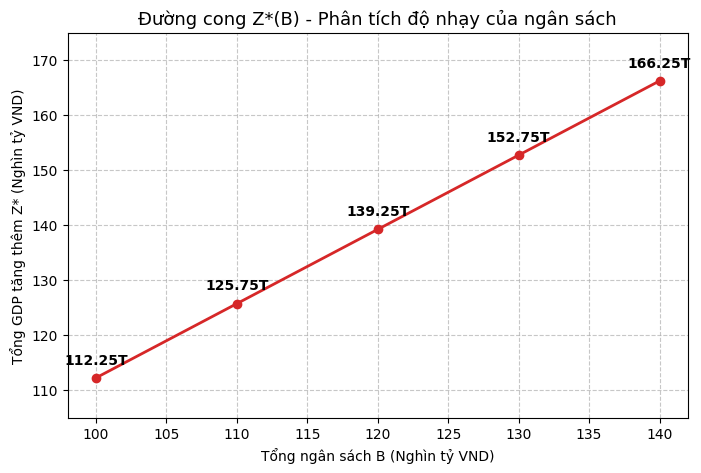

In [2]:
print("=== CÂU 2.4.3: PHÂN TÍCH ĐỘ NHẠY Z*(B) ===")
budgets = [100, 110, 120, 130, 140]
z_values = []
allocation_history = []

for b in budgets:
    prob_sens = pulp.LpProblem(f"Budget_{b}", pulp.LpMaximize)
    y1 = pulp.LpVariable('y1', lowBound=0); y2 = pulp.LpVariable('y2', lowBound=0)
    y3 = pulp.LpVariable('y3', lowBound=0); y4 = pulp.LpVariable('y4', lowBound=0)
    
    prob_sens += 0.85*y1 + 1.20*y2 + 0.95*y3 + 1.35*y4
    
    prob_sens += (y1 + y2 + y3 + y4 <= b)
    prob_sens += (y1 >= 25); prob_sens += (y2 >= 15); prob_sens += (y3 >= 20); prob_sens += (y4 >= 10)
    prob_sens += (y2 + y4 >= 0.35 * (y1 + y2 + y3 + y4))
    
    prob_sens.solve(pulp.PULP_CBC_CMD(msg=False))
    z_values.append(pulp.value(prob_sens.objective))
    allocation_history.append([y1.varValue, y2.varValue, y3.varValue, y4.varValue])

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.plot(budgets, z_values, marker='o', color='#d62728', linestyle='-', linewidth=2)

# Annotation giá trị Z*
for i, txt in enumerate(z_values):
    plt.annotate(f"{txt:.2f}T", (budgets[i], z_values[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.title('Đường cong Z*(B) - Phân tích độ nhạy của ngân sách', fontsize=13)
plt.xlabel('Tổng ngân sách B (Nghìn tỷ VND)')
plt.ylabel('Tổng GDP tăng thêm Z* (Nghìn tỷ VND)')
plt.ylim(105, 175)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Bình luận độ nhạy:** Biểu đồ cho thấy Z*(B) là một đường thẳng đi lên. Độ dốc (slope) của đường này là: 
$\frac{\Delta Z}{\Delta B} = \frac{139.25 - 112.25}{120 - 100} = 1.35$
Điều này minh chứng cho tính chất của Shadow Price đã phân tích ở trên: Độ dốc của hàm mục tiêu theo biến động tài nguyên chính là shadow price của ràng buộc tài nguyên đó (1.35).

## Câu 2.4.4 - Ưu tiên nhân lực số với ràng buộc mới $x_3 \ge 30$

In [8]:
print("=== CÂU 2.4.4: ƯU TIÊN NHÂN LỰC SỐ (x3 >= 30) ===")
prob_x3 = pulp.LpProblem("Budget_Allocation_x3_30", pulp.LpMaximize)

z1 = pulp.LpVariable('z1', lowBound=0); z2 = pulp.LpVariable('z2', lowBound=0)
z3 = pulp.LpVariable('z3', lowBound=0); z4 = pulp.LpVariable('z4', lowBound=0)

prob_x3 += 0.85*z1 + 1.20*z2 + 0.95*z3 + 1.35*z4

prob_x3 += (z1 + z2 + z3 + z4 <= 100)
prob_x3 += (z1 >= 25); prob_x3 += (z2 >= 15)
prob_x3 += (z3 >= 30)  # Ràng buộc mới
prob_x3 += (z4 >= 10)
prob_x3 += (z2 + z4 >= 0.35 * (z1 + z2 + z3 + z4))

prob_x3.solve(pulp.PULP_CBC_CMD(msg=False))
status = pulp.LpStatus[prob_x3.status]

z_x3 = pulp.value(prob_x3.objective)
x_x3 = [z1.varValue, z2.varValue, z3.varValue, z4.varValue]

print(f"Trạng thái khả thi: {status}")
if status == 'Optimal':
    print(f"Phân bổ mới (x1, x2, x3, x4): {x_x3}")
    print(f"Giá trị Z* = {z_x3} nghìn tỷ VND")
    print(f"Mức thay đổi Z* so với ban đầu: {z_x3 - z_base:.2f} nghìn tỷ VND")

=== CÂU 2.4.4: ƯU TIÊN NHÂN LỰC SỐ (x3 >= 30) ===
Trạng thái khả thi: Optimal
Phân bổ mới (x1, x2, x3, x4): [25.0, 15.0, 30.0, 30.0]
Giá trị Z* = 108.25 nghìn tỷ VND
Mức thay đổi Z* so với ban đầu: -4.00 nghìn tỷ VND


**Giải thích tính khả thi và sự đánh đổi (Trade-off):**
- **Khả thi:** Bài toán vẫn khả thi vì tổng hạn mức tối thiểu mới của 4 hạng mục là $25 + 15 + 30 + 10 = 80$, vẫn nhỏ hơn hoặc bằng tổng ngân sách $100$.
- **Sự thay đổi Z\*:** Z* giảm mất $4.0$ nghìn tỷ (từ $112.25$ xuống $108.25$). Nguyên nhân cốt lõi là do mô hình bị tước đi 10 nghìn tỷ ở hạng mục có biên lợi nhuận cao nhất ($x_4$: 1.35) để chuyển sang cho $x_3$ (có biên lợi nhuận thấp hơn: 0.95). Lượng tổn thất chính xác là: $10 \times (0.95 - 1.35) = -4$.

### Bảng DataFrame so sánh

In [9]:
print("=== BẢNG TỔNG HỢP SO SÁNH CÁC KỊCH BẢN ===")
scenarios = {
    "Kịch bản": ["B=100 (Gốc)", "B=120", "B=140", "B=100, x3>=30"],
    "Hạ tầng (x1)": [x_base[0], allocation_history[2][0], allocation_history[4][0], x_x3[0]],
    "AI (x2)": [x_base[1], allocation_history[2][1], allocation_history[4][1], x_x3[1]],
    "Nhân lực (x3)": [x_base[2], allocation_history[2][2], allocation_history[4][2], x_x3[2]],
    "R&D (x4)": [x_base[3], allocation_history[2][3], allocation_history[4][3], x_x3[3]],
    "Tổng Z*": [z_base, z_values[2], z_values[4], z_x3]
}

df_summary = pd.DataFrame(scenarios)
display(df_summary)

=== BẢNG TỔNG HỢP SO SÁNH CÁC KỊCH BẢN ===


,Kịch bản,Hạ tầng (x1),AI (x2),Nhân lực (x3),R&D (x4),Tổng Z*
0,B=100 (Gốc),25.0,15.0,20.0,40.0,112.25
1,B=120,25.0,15.0,20.0,60.0,139.25
2,B=140,25.0,15.0,20.0,80.0,166.25
3,"B=100, x3>=30",25.0,15.0,30.0,30.0,108.25


### Biểu đồ nhóm cột so sánh phân bổ

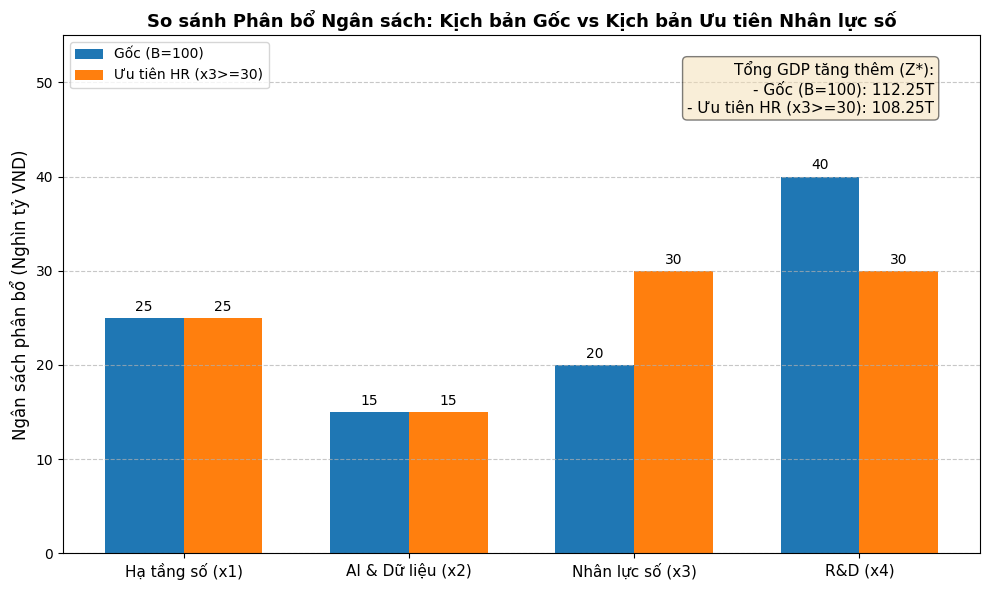

In [11]:
# Sửa lỗi trực quan hóa: Biểu đồ cột ghép (Grouped bar chart) để so sánh phân bổ
labels = ['Hạ tầng số (x1)', 'AI & Dữ liệu (x2)', 'Nhân lực số (x3)', 'R&D (x4)']
x = np.arange(len(labels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))
rects1 = ax1.bar(x - width/2, x_base, width, label='Gốc (B=100)', color='#1f77b4')
rects2 = ax1.bar(x + width/2, x_x3, width, label='Ưu tiên HR (x3>=30)', color='#ff7f0e')

ax1.set_ylabel('Ngân sách phân bổ (Nghìn tỷ VND)', fontsize=12)
ax1.set_title('So sánh Phân bổ Ngân sách: Kịch bản Gốc vs Kịch bản Ưu tiên Nhân lực số', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylim(0, max(max(x_base), max(x_x3)) + 15)
ax1.legend(loc='upper left')

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)

# Đưa tổng Z* vào một Text Box chuẩn hóa (sử dụng biến động, không hardcode)
textstr = f"Tổng GDP tăng thêm (Z*):\n- Gốc (B=100): {z_base:.2f}T\n- Ưu tiên HR (x3>=30): {z_x3:.2f}T"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', bbox=props)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Câu hỏi mục 2.5

## Câu hỏi thảo luận chính sách (Giải quyết yêu cầu 2.5)

**1. Tại sao R&D không bị ràng buộc trần lại chiếm hết phần ngân sách dư?**
Quy hoạch tuyến tính hoạt động với giả định về "tuyến tính nghiêm ngặt", nó sẽ tự động dồn tất cả tiền bạc khả dụng vào duy nhất một dự án mang lại lợi tức biên cao nhất (ở đây là $x_4$, do hệ số 1.35 > 1.20 > 0.95 > 0.85). Trong thực tế điều này không hợp lý vì ngân lực giải ngân R&D bị giới hạn bởi số lượng nhà khoa học hoặc thiết bị phòng Lab. Đây chính là điểm mù của mô hình đơn giản này. Cần bổ sung các giới hạn biên trên (upper bounds) cho tính hấp thụ vốn.

**2. Đánh đổi trong ngắn hạn vs Tác động dài hạn của việc ép $x_3 \ge 30$?**
Việc ép buộc đầu tư nhiều hơn cho $x_3$ khiến Z* ngắn hạn giảm đi 4 nghìn tỷ. Đây là một chi phí cơ hội. Tuy nhiên, nếu thiếu đi kỹ sư AI (nhân lực số), các dự án R&D và nền tảng AI có thể không thể triển khai thực tế. Do đó, cái giá 4 nghìn tỷ bị mất theo toán học có thể lại là "chi phí bảo hiểm" để toàn bộ kế hoạch công nghệ số không bị sụp đổ trong tương lai.